=== Система розрахунку на базі Fuzzy Logic (Centroid) ===
Введіть суму чека (грн): 777
Смак замовлення (0-10): 5
Затишність інтер'єру (0-10): 7
Якість обслуговування (0-10): 4

Загальна оцінка закладу: 5.3/10
Рекомендований відсоток чайових: 11.30%
Сума чайових: 87.77 грн
Разом до сплати: 864.77 грн


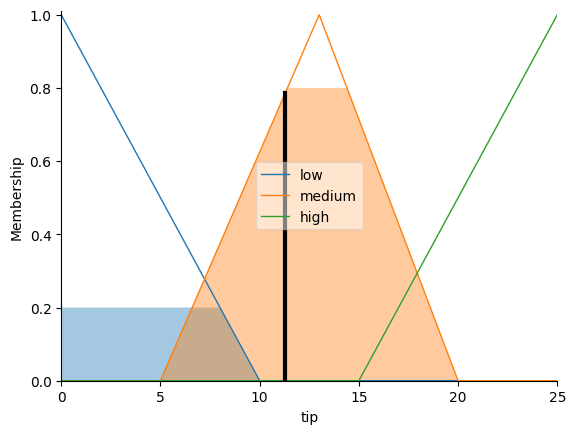

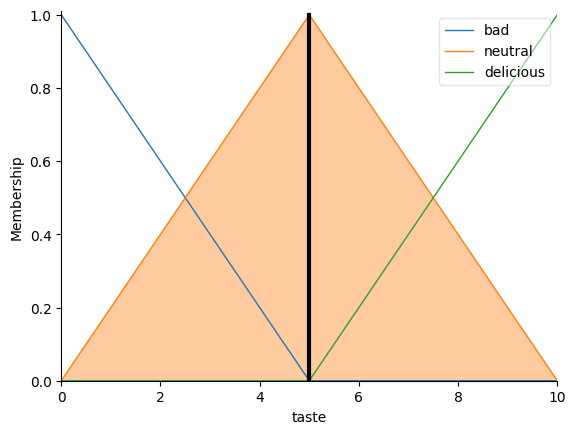

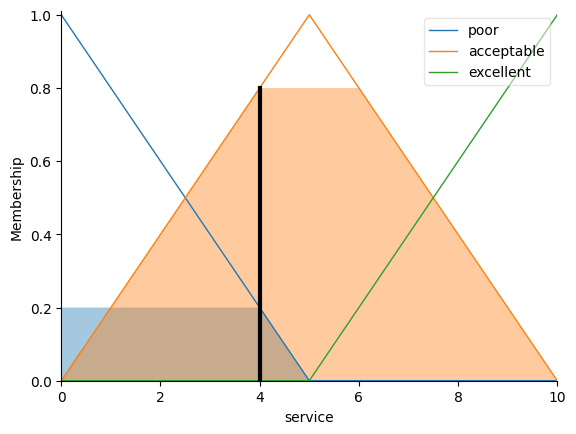

In [11]:
import numpy as np
import skfuzzy as fuzzy
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

def run_pro_tipping_system():
    #Налаштування нечітких змінних
    taste = ctrl.Antecedent(np.arange(0, 11, 1), 'taste')
    env = ctrl.Antecedent(np.arange(0, 11, 1), 'environment')
    service = ctrl.Antecedent(np.arange(0, 11, 1), 'service')
    tip = ctrl.Consequent(np.arange(0, 26, 1), 'tip')

    #Функції належності
    taste.automf(3, names=['bad', 'neutral', 'delicious'])
    env.automf(3, names=['uncomfortable', 'normal', 'cozy'])
    service.automf(3, names=['poor', 'acceptable', 'excellent'])

    #трикутні функції для чайових
    tip['low'] = fuzzy.trimf(tip.universe, [0, 0, 10])
    tip['medium'] = fuzzy.trimf(tip.universe, [5, 13, 20])
    tip['high'] = fuzzy.trimf(tip.universe, [15, 25, 25])

    #База правил
    rules = [
        ctrl.Rule(service['poor'] | taste['bad'], tip['low']),
        ctrl.Rule(service['acceptable'], tip['medium']),
        ctrl.Rule(service['excellent'] | taste['delicious'], tip['high']),
        ctrl.Rule(env['cozy'] & service['excellent'], tip['high'])
    ]

    tipping_ctrl = ctrl.ControlSystem(rules)
    simulation = ctrl.ControlSystemSimulation(tipping_ctrl)

    #Введення даних від користувача
    print("Система розрахунку чайових ")
    try:
        bill = float(input("Введіть суму чека: "))
        t_val = float(input("Смак замовлення (0-10): "))
        e_val = float(input("Затишність інтер'єру (0-10): "))
        s_val = float(input("Якість обслуговування (0-10): "))


        simulation.input['taste'] = t_val
        simulation.input['environment'] = e_val
        simulation.input['service'] = s_val

        # Дефазифікація
        simulation.compute()

        tip_percent = simulation.output['tip']

        overall_score = (t_val + e_val + s_val) / 3
        tip_amount = (bill * tip_percent) / 100
        total_to_pay = bill + tip_amount

        print("\n" + "="*40)
        print(f"Загальна оцінка закладу: {overall_score:.1f}/10")
        print(f"Рекомендований відсоток чайових: {tip_percent:.2f}%")
        print(f"Сума чайових: {tip_amount:.2f} грн")
        print(f"Разом до сплати: {total_to_pay:.2f} грн")
        print("="*40)

        #Візуалізація дефазифікації
        tip.view(sim=simulation)
        plt.show()

    except ValueError:
        print("Помилка: будь ласка, вводьте коректні числа.")

if __name__ == "__main__":
    run_pro_tipping_system()
